In [ ]:
# https://medium.com/@nadavlevi/visualising-mri-data-in-python-fe010c4a1c54 <--visualization of FastMRI dataset

# 1# Imports and Environment Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Update pip and install required packages
!pip install --upgrade pip

# Install core packages
!pip install numpy scipy matplotlib pandas

# Medical imaging libraries
!pip install pydicom nibabel SimpleITK

# General image processing
!pip install scikit-image opencv-python

!pip install fastmri nibabel


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pydicom]
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install requests h5py

In [ ]:
import os
# environment variable to handle OpenMP conflicts before importing other libraries
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import h5py
import numpy as np
import matplotlib.pyplot as plt
# Import reconstruction function from fastmri
try:
    from fastmri.fftc import ifft2c_new
    FASTMRI_AVAILABLE = True
    print("FastMRI library imported successfully.")
except ImportError as e:
    print(f"FastMRI import failed: {e}")
    print("Will use manual reconstruction with numpy FFT.")
    FASTMRI_AVAILABLE = False
import nibabel as nib

FastMRI library imported successfully.


In [ ]:
import os
# --- Configuration ---
#Sets the directory where the program should look for files.
data_folder = "/content/drive/MyDrive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2"

# Find one .h5 file to inspect
h5_file_path = None
for root, _, files in os.walk(data_folder):
    for file in files:
        if file.endswith(".h5"):
            h5_file_path = os.path.join(root, file)
            break
    if h5_file_path:
        break

if h5_file_path is None:
    print(f"Error: No .h5 files found in {data_folder}. Please check the path and contents.")
    exit()

print(f"Inspecting file: {h5_file_path}")


Inspecting file: /content/drive/MyDrive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2/file_brain_AXFLAIR_201_6002891.h5


## 2# Reconstruction & normalization

In [ ]:
#process, normalize and save data
import h5py
import numpy as np
import os
from PIL import Image
import nibabel as nib

# Try to import FastMRI functions, fall back to manual reconstruction if not available
try:
    from fastmri.fftc import ifft2c_new
    FASTMRI_AVAILABLE = True
except ImportError:
    print("FastMRI library not available, using manual reconstruction")
    FASTMRI_AVAILABLE = False

def manual_ifft2c(kspace_data):
    """Manual implementation of centered 2D IFFT"""
    return np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(kspace_data)))

def safe_fastmri_reconstruction(kspace_slice):
    """
    Safely attempt FastMRI reconstruction with fallback to manual method
    """
    try:
        if FASTMRI_AVAILABLE:
            # Prepare for ifft2c_new: ensure proper shape and data type
            if np.iscomplexobj(kspace_slice):
                # Convert complex to real/imaginary components
                real_part = kspace_slice.real
                imag_part = kspace_slice.imag
                separated = np.stack([real_part, imag_part], axis=-1)
            else:
                # If already real, assume it's magnitude and set imaginary to zero
                separated = np.stack([kspace_slice, np.zeros_like(kspace_slice)], axis=-1)

            # Add batch dimension if needed
            if separated.ndim == 3:
                separated = np.expand_dims(separated, axis=0)

            # Try FastMRI reconstruction
            reco = ifft2c_new(separated)
            reco_complex = reco[..., 0] + 1j * reco[..., 1]
            return reco_complex[0] if reco_complex.ndim > 2 else reco_complex
        else:
            # Use manual reconstruction
            return manual_ifft2c(kspace_slice)
    except Exception as e:
        print(f"    FastMRI reconstruction failed: {e}, using manual method")
        return manual_ifft2c(kspace_slice)

# --- Configuration ---
input_data_folder = "/content/drive/MyDrive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2"
output_folder_png = "./processed_images_png"
output_folder_npy = "./processed_images_npy"
output_folder_nifti = "./processed_images_nifti"
max_files_to_process = 6

os.makedirs(output_folder_png, exist_ok=True)
os.makedirs(output_folder_npy, exist_ok=True)
os.makedirs(output_folder_nifti, exist_ok=True)

print(f"Starting preprocessing from: {input_data_folder}")
print(f"Output PNGs to: {output_folder_png}")
print(f"Output NumPy arrays to: {output_folder_npy}")
print(f"Output NIfTI files to: {output_folder_nifti}")
print(f"Processing a maximum of {max_files_to_process} files.")

processed_count = 0

example_raw_image_data = None
example_normalized_image_data = None
example_kspace_data = None
example_reco_magnitude_slice = None

for root, _, files in os.walk(input_data_folder):
    for filename in files:
        if filename.endswith(".h5"):
            if processed_count >= max_files_to_process:
                print(f"Reached maximum of {max_files_to_process} files. Stopping.")
                break

            file_path = os.path.join(root, filename)
            scan_id = os.path.splitext(filename)[0]
            print(f"\nProcessing {scan_id}...")

            try:
                current_image_data = None
                with h5py.File(file_path, 'r') as f:
                    # Print available keys for debugging
                    print(f"  Available keys in HDF5 file: {list(f.keys())}")

                    if 'reconstruction_rss' in f:
                        current_image_data = f['reconstruction_rss'][()]
                        print(f"  Loaded 'reconstruction_rss' with shape: {current_image_data.shape}")
                    elif 'reconstruction_esc' in f:
                        current_image_data = f['reconstruction_esc'][()]
                        print(f"  Loaded 'reconstruction_esc' with shape: {current_image_data.shape}")
                    elif 'kspace' in f:
                        print(f"  'reconstruction_rss'/'reconstruction_esc' not found. Reconstructing from 'kspace'.")
                        kspace_data = f['kspace'][()]  # (slices, coils, height, width)
                        print(f"  K-space data shape: {kspace_data.shape}")
                        print(f"  K-space data type: {kspace_data.dtype}")

                        reconstructed_slices = []

                        for i in range(kspace_data.shape[0]):  # Iterate through slices
                            slice_kspace = kspace_data[i]  # (coils, height, width)
                            reco_coils = []

                            for coil in range(slice_kspace.shape[0]):
                                single_coil_kspace = slice_kspace[coil]

                                # Use safe reconstruction function
                                reco_coil = safe_fastmri_reconstruction(single_coil_kspace)
                                reco_coils.append(reco_coil)

                            # RSS (Root Sum of Squares) across coils
                            reco_coils = np.stack(reco_coils, axis=0)
                            reco_rss = np.sqrt(np.sum(np.abs(reco_coils) ** 2, axis=0))
                            reconstructed_slices.append(reco_rss)

                            # Store example k-space and reco slice for visualization
                            if example_kspace_data is None and i == kspace_data.shape[0] // 2:
                                example_kspace_data = slice_kspace
                                example_reco_magnitude_slice = reco_rss

                        current_image_data = np.stack(reconstructed_slices, axis=0)
                        print(f"  Reconstructed image data shape: {current_image_data.shape}")
                    else:
                        print(f"  No reconstructible data found in {filename}. Skipping.")
                        continue

                    # Handle complex data
                    if np.iscomplexobj(current_image_data):
                        current_image_data = np.abs(current_image_data)
                        print("  Converted complex image data to absolute values.")

                    # Store example data
                    if example_raw_image_data is None:
                        middle_slice_index = current_image_data.shape[0] // 2
                        example_raw_image_data = current_image_data[middle_slice_index].copy()
                        print(f"  Stored raw data from middle slice {middle_slice_index} for visualization.")

                    # Normalize data
                    min_val = np.min(current_image_data)
                    max_val = np.max(current_image_data)
                    if max_val - min_val > 0:
                        normalized_image_data_current = (current_image_data - min_val) / (max_val - min_val)
                        print(f"  Normalized image data from [{min_val:.2f}, {max_val:.2f}] to [0, 1].")
                    else:
                        normalized_image_data_current = current_image_data
                        print("  Image data is uniform, skipping normalization.")

                    if example_normalized_image_data is None:
                        example_normalized_image_data = normalized_image_data_current[middle_slice_index].copy()
                        print(f"  Stored normalized data from middle slice {middle_slice_index} for visualization.")

                    num_slices = normalized_image_data_current.shape[0]

                    # --- Save as NIfTI (.nii.gz) ---
                    nifti_data = normalized_image_data_current.transpose(1, 2, 0)
                    affine = np.eye(4)
                    nifti_img = nib.Nifti1Image(nifti_data.astype(np.float32), affine)
                    nifti_output_path = os.path.join(output_folder_nifti, f"{scan_id}.nii.gz")
                    nib.save(nifti_img, nifti_output_path)
                    print(f"  Saved 3D NIfTI: {nifti_output_path}")

                    # --- Save each slice as PNG and NumPy array ---
                    for i in range(num_slices):
                        slice_data = normalized_image_data_current[i]
                        png_data = (slice_data * 255).astype(np.uint8)
                        png_filename = f"{scan_id}_slice_{i:03d}.png"
                        Image.fromarray(png_data).save(os.path.join(output_folder_png, png_filename))
                        npy_filename = f"{scan_id}_slice_{i:03d}.npy"
                        np.save(os.path.join(output_folder_npy, npy_filename), slice_data.astype(np.float32))

                    print(f"  Processed {num_slices} slices for {scan_id}.")
                    processed_count += 1

            except Exception as e:
                print(f"  Error processing {filename}: {e}")
                import traceback
                traceback.print_exc()

print(f"\nPreprocessing finished. Processed {processed_count} files.")
print(f"Check '{output_folder_png}', '{output_folder_npy}', and '{output_folder_nifti}' for results.")

# --- Save the example data for later visualization ---
if example_raw_image_data is not None:
    np.save('example_raw_image_slice.npy', example_raw_image_data)
    np.save('example_normalized_image_slice.npy', example_normalized_image_data)
    if example_kspace_data is not None:
        np.save('example_kspace_slice.npy', example_kspace_data)
    if example_reco_magnitude_slice is not None:
        np.save('example_reco_magnitude_slice.npy', example_reco_magnitude_slice)
    print("\nExample data (raw, normalized, kspace, reconstructed) saved as .npy files for visualization.")

Starting preprocessing from: /content/drive/MyDrive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2
Output PNGs to: ./processed_images_png
Output NumPy arrays to: ./processed_images_npy
Output NIfTI files to: ./processed_images_nifti
Processing a maximum of 6 files.

Processing file_brain_AXFLAIR_201_6002891...
  Available keys in HDF5 file: ['ismrmrd_header', 'kspace', 'mask']
  'reconstruction_rss'/'reconstruction_esc' not found. Reconstructing from 'kspace'.
  K-space data shape: (16, 16, 640, 320)
  K-space data type: complex64
    FastMRI reconstruction failed: 'int' object is not callable, using manual method
    FastMRI reconstruction failed: 'int' object is not callable, using manual method
    FastMRI reconstruction failed: 'int' object is not callable, using manual method
    FastMRI reconstruction failed: 'int' object is not callable, using manual method
    FastMRI reconstruction failed: 'int' object is not callable, using manual method
    FastMRI reconstr

## 3# Explore a sample file





--- H5 File Structure ---
ismrmrd_header
kspace
mask

--- Available Keys/Datasets ---
- ismrmrd_header
- kspace
- mask

--- 'reconstruction_rss' not found. Performing RSS reconstruction from 'kspace' data ---
Shape of kspace_data: (16, 20, 768, 396)
Data type: complex64
Is complex: True
Reconstructed image data shape: (16, 768, 396)
After normalization - Min: 0.0, Max: 1.0


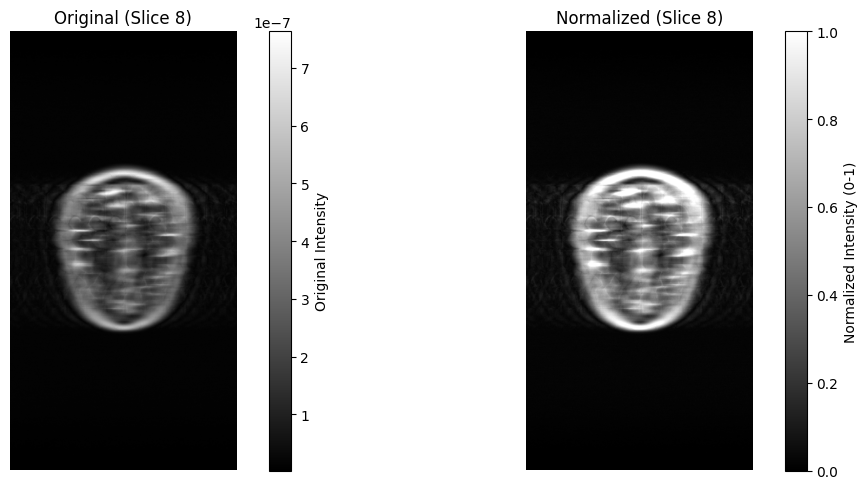

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

h5_file_path = "/content/drive/My Drive/Alzheimer_DL_detection/MRI datasets/multicoil_test/file_brain_AXT2_200_6002633.h5"  # Update with your file path

try:
    with h5py.File(h5_file_path, 'r') as f:
        print("\n--- H5 File Structure ---")
        def print_attrs(name, obj):
            print(name)
            for key, val in obj.attrs.items():
                print(f"    {key}: {val}")
        f.visititems(print_attrs)

        print("\n--- Available Keys/Datasets ---")
        for key in f.keys():
            print(f"- {key}")

        # Check for 'reconstruction_rss'
        if 'reconstruction_rss' in f:
            print("\n--- Extracting 'reconstruction_rss' data (already reconstructed) ---")
            image_data = f['reconstruction_rss'][()]
            print(f"Shape of image_data: {image_data.shape}")
            print(f"Data type: {image_data.dtype}")
            print(f"Min value: {np.min(image_data)}")
            print(f"Max value: {np.max(image_data)}")
            if np.iscomplexobj(image_data):
                image_data = np.abs(image_data)

            # Display logic
            if image_data.ndim >= 3:
                middle_slice_index = image_data.shape[0] // 2
                slice_to_display = image_data[middle_slice_index]
                if slice_to_display.ndim == 3:
                    print(f"Warning: Slice has 3 dimensions ({slice_to_display.shape}), showing first 'coil' or channel.")
                    slice_to_display = slice_to_display[0]
                plt.figure(figsize=(8, 8))
                plt.imshow(slice_to_display, cmap='gray')
                plt.title(f'Middle Slice (Index: {middle_slice_index}) from reconstruction_rss')
                plt.colorbar(label='Pixel Intensity')
                plt.axis('off')
                plt.show()
            else:
                print("Image data has fewer than 3 dimensions, cannot display as a slice image.")

        # If only k-space is present (multicoil)
        elif 'kspace' in f:
            print("\n--- 'reconstruction_rss' not found. Performing RSS reconstruction from 'kspace' data ---")
            kspace_data = f['kspace'][()]
            print(f"Shape of kspace_data: {kspace_data.shape}")
            print(f"Data type: {kspace_data.dtype}")
            print(f"Is complex: {np.iscomplexobj(kspace_data)}")

            reconstructed_slices = []
            for i in range(kspace_data.shape[0]):  # Slices
                slice_kspace = kspace_data[i]  # (coils, height, width)
                reco_coils = []
                for coil in range(slice_kspace.shape[0]):
                    single_coil_kspace = slice_kspace[coil]
                    reco = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(single_coil_kspace)))
                    reco_coils.append(reco)
                reco_coils = np.stack(reco_coils, axis=0)
                reco_rss = np.sqrt(np.sum(np.abs(reco_coils) ** 2, axis=0))
                reconstructed_slices.append(reco_rss)
            image_data = np.stack(reconstructed_slices, axis=0)
            print(f"Reconstructed image data shape: {image_data.shape}")

            # Normalize for visualization
            image_data_norm = image_data.copy()
            p1, p99 = np.percentile(image_data_norm, [1, 99])
            image_data_norm = np.clip(image_data_norm, p1, p99)
            if np.max(image_data_norm) > np.min(image_data_norm):
                image_data_norm = (image_data_norm - np.min(image_data_norm)) / (np.max(image_data_norm) - np.min(image_data_norm))
            print(f"After normalization - Min: {np.min(image_data_norm)}, Max: {np.max(image_data_norm)}")

            # Display the middle slice
            middle_slice_index = image_data.shape[0] // 2
            slice_to_display = image_data_norm[middle_slice_index]

            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(image_data[middle_slice_index], cmap='gray')
            plt.title(f'Original (Slice {middle_slice_index})')
            plt.colorbar(label='Original Intensity')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(slice_to_display, cmap='gray')
            plt.title(f'Normalized (Slice {middle_slice_index})')
            plt.colorbar(label='Normalized Intensity (0-1)')
            plt.axis('off')

            plt.tight_layout()
            plt.show()
        else:
            print("Neither 'reconstruction_rss', 'reconstruction_esc', nor 'kspace' found. Cannot display image.")

except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure the .h5 file is not corrupted, the path is correct, and fastmri is installed.")
    import traceback
    traceback.print_exc()


Processing MRI images

In [ ]:
#create output directories
import os
from PIL import Image

# Set environment variable to handle OpenMP conflicts before importing other libraries
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# --- Configuration for Brain Multicoil MRI ---
input_data_folder = "/content/drive/MyDrive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2"  # Update this to your actual brain multicoil data folder
output_folder_png = "./processed_images_png"      # Output for PNGs
output_folder_npy = "./processed_images_npy"      # Output for NumPy arrays (for ML)
output_folder_nifti = "./processed_images_nifti"  # Output for NIfTI (medical image format)
max_files_to_process = 6 # Process only 10 files for testing

# Ensure output directories exist
os.makedirs(output_folder_png, exist_ok=True)
os.makedirs(output_folder_npy, exist_ok=True)
os.makedirs(output_folder_nifti, exist_ok=True)

print(f"Starting preprocessing from: {input_data_folder}")
print(f"Output PNGs to: {output_folder_png}")
print(f"Output NumPy arrays to: {output_folder_npy}")
print(f"Output NIfTI files to: {output_folder_nifti}")
print(f"Processing a maximum of {max_files_to_process} files.")


Starting preprocessing from: /content/drive/MyDrive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2
Output PNGs to: ./processed_images_png
Output NumPy arrays to: ./processed_images_npy
Output NIfTI files to: ./processed_images_nifti
Processing a maximum of 6 files.


In [ ]:
import os
import numpy as np
import h5py
import nibabel as nib
from PIL import Image

# Set up paths for multicoil brain dataset
input_data_folder = "/content/drive/My Drive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2"
output_base_folder = "/content/drive/My Drive/Alzheimer_DL_detection/processed_brain_multicoil"

# Create output directories
output_folder_png = os.path.join(output_base_folder, "png_slices")
output_folder_npy = os.path.join(output_base_folder, "npy_slices")
output_folder_nifti = os.path.join(output_base_folder, "nifti_volumes")

for folder in [output_folder_png, output_folder_npy, output_folder_nifti]:
    os.makedirs(folder, exist_ok=True)

# Configuration
max_files_to_process = 100  # Adjust as needed

# Check for FastMRI availability
FASTMRI_AVAILABLE = False
try:
    from fastmri.data.transforms import ifft2c_new
    FASTMRI_AVAILABLE = True
    print("FastMRI library available - using optimized reconstruction.")
except ImportError:
    print("FastMRI library not available - using manual reconstruction.")

def root_sum_of_squares(coil_images):
    """
    Combine multicoil images using root sum of squares method.

    Args:
        coil_images: Complex array of shape (num_coils, height, width)

    Returns:
        Combined magnitude image of shape (height, width)
    """
    return np.sqrt(np.sum(np.abs(coil_images)**2, axis=0))

def manual_ifft2c(kspace_data):
    """
    Manual inverse FFT with centering for multicoil data.

    Args:
        kspace_data: Complex k-space data of shape (num_coils, height, width)

    Returns:
        Image space data of shape (num_coils, height, width)
    """
    # Apply inverse FFT to each coil
    image_data = np.zeros_like(kspace_data)
    for coil in range(kspace_data.shape[0]):
        image_data[coil] = np.fft.ifftshift(
            np.fft.ifft2(np.fft.fftshift(kspace_data[coil]))
        )
    return image_data

def process_multicoil_kspace(kspace_data, scan_id, slice_idx):
    """
    Process multicoil k-space data to get final magnitude image.

    Args:
        kspace_data: Complex k-space data of shape (num_coils, height, width)
        scan_id: Identifier for the scan
        slice_idx: Slice index for logging

    Returns:
        Final magnitude image of shape (height, width)
    """
    print(f"    Processing slice {slice_idx}: k-space shape {kspace_data.shape}")

    if FASTMRI_AVAILABLE:
        try:
            # Convert to format expected by FastMRI
            if np.iscomplexobj(kspace_data):
                # Stack real and imaginary parts as last dimension
                kspace_separated = np.stack([kspace_data.real, kspace_data.imag], axis=-1)
            else:
                print(f"    Warning: k-space slice {slice_idx} is not complex. Creating zero imaginary part.")
                kspace_separated = np.stack([kspace_data, np.zeros_like(kspace_data)], axis=-1)

            # Try to convert to torch tensor if needed
            try:
                import torch
                kspace_tensor = torch.from_numpy(kspace_separated.astype(np.float32))
                image_space_separated = ifft2c_new(kspace_tensor).numpy()
            except ImportError:
                # If torch is not available, try with numpy array directly
                image_space_separated = ifft2c_new(kspace_separated)

            # Convert back to numpy complex format
            if image_space_separated.shape[-1] == 2:  # Has complex dimension
                image_space_complex = image_space_separated[..., 0] + 1j * image_space_separated[..., 1]
            else:
                image_space_complex = image_space_separated

        except Exception as e:
            print(f"    FastMRI reconstruction failed for slice {slice_idx}: {e}")
            print("    Falling back to manual inverse FFT...")
            image_space_complex = manual_ifft2c(kspace_data)
    else:
        # Manual reconstruction using numpy FFT
        image_space_complex = manual_ifft2c(kspace_data)

    # Combine coils using root sum of squares
    final_magnitude = root_sum_of_squares(image_space_complex)

    return final_magnitude

# Main processing loop
processed_count = 0

for root, _, files in os.walk(input_data_folder):
    for filename in files:
        if filename.endswith(".h5"):
            if processed_count >= max_files_to_process:
                print(f"Reached maximum of {max_files_to_process} files. Stopping.")
                break

            file_path = os.path.join(root, filename)
            scan_id = os.path.splitext(filename)[0] # e.g., 'file1000000'

            print(f"\nProcessing {scan_id}...")

            try:
                image_data = None # Initialize image_data
                with h5py.File(file_path, 'r') as f:
                    # Print available keys for debugging
                    print(f"  Available keys in HDF5 file: {list(f.keys())}")

                    # Prefer 'reconstruction_rss' if it exists
                    if 'reconstruction_rss' in f:
                        image_data = f['reconstruction_rss'][()]
                        print(f"  Loaded 'reconstruction_rss' with shape: {image_data.shape}")
                    elif 'reconstruction_esc' in f:
                        image_data = f['reconstruction_esc'][()]
                        print(f"  Loaded 'reconstruction_esc' with shape: {image_data.shape}")
                    elif 'kspace' in f:
                        print(f"  'reconstruction_rss'/'reconstruction_esc' not found. Reconstructing from 'kspace'.")
                        kspace_data = f['kspace'][()]
                        print(f"  K-space data shape: {kspace_data.shape}")
                        print(f"  K-space data type: {kspace_data.dtype}")
                        print(f"  Is complex: {np.iscomplexobj(kspace_data)}")

                        reconstructed_slices = []

                        # Handle different possible k-space data shapes
                        if len(kspace_data.shape) == 4:  # (slices, coils, height, width)
                            num_slices = kspace_data.shape[0]
                            print(f"  Processing {num_slices} slices with multicoil data...")

                            for i in range(num_slices):
                                slice_kspace = kspace_data[i]  # (coils, height, width)
                                final_magnitude = process_multicoil_kspace(slice_kspace, scan_id, i)
                                reconstructed_slices.append(final_magnitude)

                        elif len(kspace_data.shape) == 3:  # (coils, height, width) - single slice
                            print(f"  Processing single slice with multicoil data...")
                            final_magnitude = process_multicoil_kspace(kspace_data, scan_id, 0)
                            reconstructed_slices.append(final_magnitude)

                        else:
                            print(f"  Unexpected k-space shape: {kspace_data.shape}")
                            # Try to handle as (slices, height, width) - single coil
                            if len(kspace_data.shape) == 3:
                                print(f"  Treating as single-coil data...")
                                for i in range(kspace_data.shape[0]):
                                    slice_kspace = kspace_data[i]
                                    # Add coil dimension
                                    slice_kspace = np.expand_dims(slice_kspace, axis=0)
                                    final_magnitude = process_multicoil_kspace(slice_kspace, scan_id, i)
                                    reconstructed_slices.append(final_magnitude)
                            else:
                                print(f"  Cannot handle k-space shape: {kspace_data.shape}. Skipping.")
                                continue

                        image_data = np.stack(reconstructed_slices, axis=0)
                        print(f"  Reconstructed image data shape: {image_data.shape}")
                    else:
                        print(f"  No reconstructible data ('reconstruction_rss', 'reconstruction_esc', or 'kspace') found in {filename}. Skipping.")
                        continue # Skip to the next file

                    # Ensure the data is real (if it's complex, take the absolute value)
                    if np.iscomplexobj(image_data):
                        image_data = np.abs(image_data)
                        print("  Converted complex image data to absolute values (post-reconstruction).")

                    # Normalization: Scale values to 0-1 with percentile-based clipping for better contrast
                    min_val = np.min(image_data)
                    max_val = np.max(image_data)
                    print(f"  Original data range: [{min_val:.2e}, {max_val:.2e}]")

                    if max_val - min_val > 0:
                        # Apply percentile-based normalization to improve contrast
                        p1, p99 = np.percentile(image_data, [1, 99])
                        print(f"  1st-99th percentile range: [{p1:.2e}, {p99:.2e}]")

                        # Clip to percentile range and normalize
                        clipped_data = np.clip(image_data, p1, p99)
                        if p99 > p1:
                            normalized_image_data = (clipped_data - p1) / (p99 - p1)
                        else:
                            normalized_image_data = clipped_data

                        print(f"  Normalized image data to [0, 1] using percentile clipping.")
                    else:
                        normalized_image_data = image_data # Already uniform, no change
                        print("  Image data is uniform, skipping normalization.")

                    # Assuming normalized_image_data is (slices, height, width)
                    num_slices = normalized_image_data.shape[0]

                    # --- Save as NIfTI (.nii.gz) for 3D medical imaging ---
                    nifti_data = normalized_image_data.transpose(1, 2, 0) # (height, width, slices)
                    affine = np.eye(4) # Identity affine matrix for basic NIfTI save
                    nifti_img = nib.Nifti1Image(nifti_data.astype(np.float32), affine) # Save as float32
                    nifti_output_path = os.path.join(output_folder_nifti, f"{scan_id}.nii.gz")
                    nib.save(nifti_img, nifti_output_path)
                    print(f"  Saved 3D NIfTI: {nifti_output_path}")

                    # --- Save each slice as PNG (for visualization) and NumPy array (for ML) ---
                    for i in range(num_slices):
                        slice_data = normalized_image_data[i] # Slice is now (height, width)

                        # Save as PNG (scaled to 0-255 for typical image display)
                        png_data = (slice_data * 255).astype(np.uint8)
                        png_filename = f"{scan_id}_slice_{i:03d}.png"
                        Image.fromarray(png_data).save(os.path.join(output_folder_png, png_filename))

                        # Save as NumPy array (float32 for ML input)
                        npy_filename = f"{scan_id}_slice_{i:03d}.npy"
                        np.save(os.path.join(output_folder_npy, npy_filename), slice_data.astype(np.float32))

                    print(f"  Processed {num_slices} slices for {scan_id}.")
                    processed_count += 1

            except Exception as e:
                print(f"  Error processing {filename}: {e}")
                import traceback
                traceback.print_exc() # Print full traceback for debugging

print(f"\nPreprocessing finished. Processed {processed_count} files.")
print(f"Check '{output_folder_png}', '{output_folder_npy}', and '{output_folder_nifti}' for results.")

FastMRI library not available - using manual reconstruction.

Processing file_brain_AXFLAIR_201_6002891...
  Available keys in HDF5 file: ['ismrmrd_header', 'kspace', 'mask']
  'reconstruction_rss'/'reconstruction_esc' not found. Reconstructing from 'kspace'.
  K-space data shape: (16, 16, 640, 320)
  K-space data type: complex64
  Is complex: True
  Processing 16 slices with multicoil data...
    Processing slice 0: k-space shape (16, 640, 320)
    Processing slice 1: k-space shape (16, 640, 320)
    Processing slice 2: k-space shape (16, 640, 320)
    Processing slice 3: k-space shape (16, 640, 320)
    Processing slice 4: k-space shape (16, 640, 320)
    Processing slice 5: k-space shape (16, 640, 320)
    Processing slice 6: k-space shape (16, 640, 320)
    Processing slice 7: k-space shape (16, 640, 320)
    Processing slice 8: k-space shape (16, 640, 320)
    Processing slice 9: k-space shape (16, 640, 320)
    Processing slice 10: k-space shape (16, 640, 320)
    Processing slic

# Data Visualizations

K-space data shape: (16, 640, 320)
Reconstructed magnitude data shape: (640, 320)
Example data loaded successfully for visualization.
Raw image shape: (640, 320)
Normalized image shape: (640, 320)


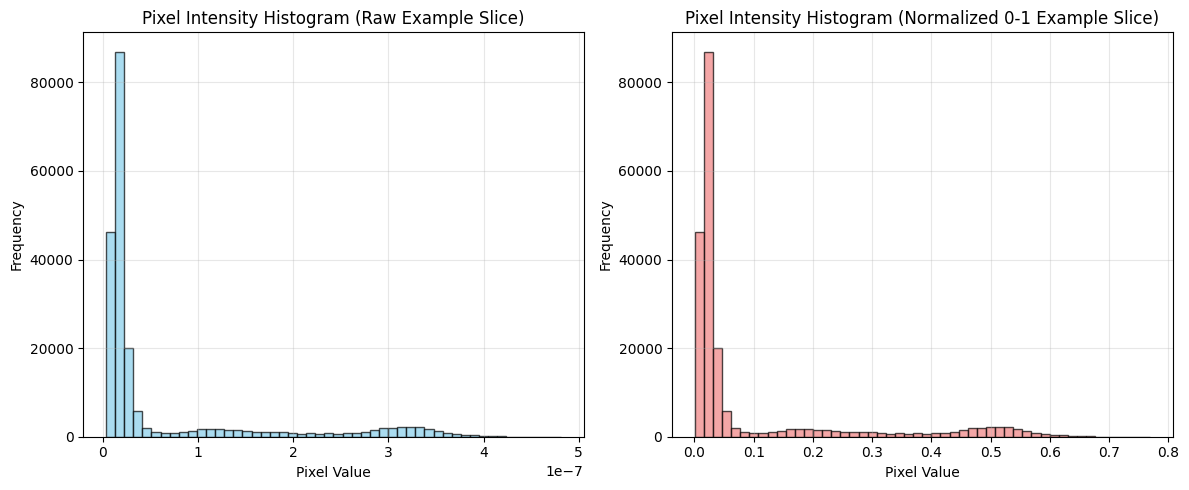

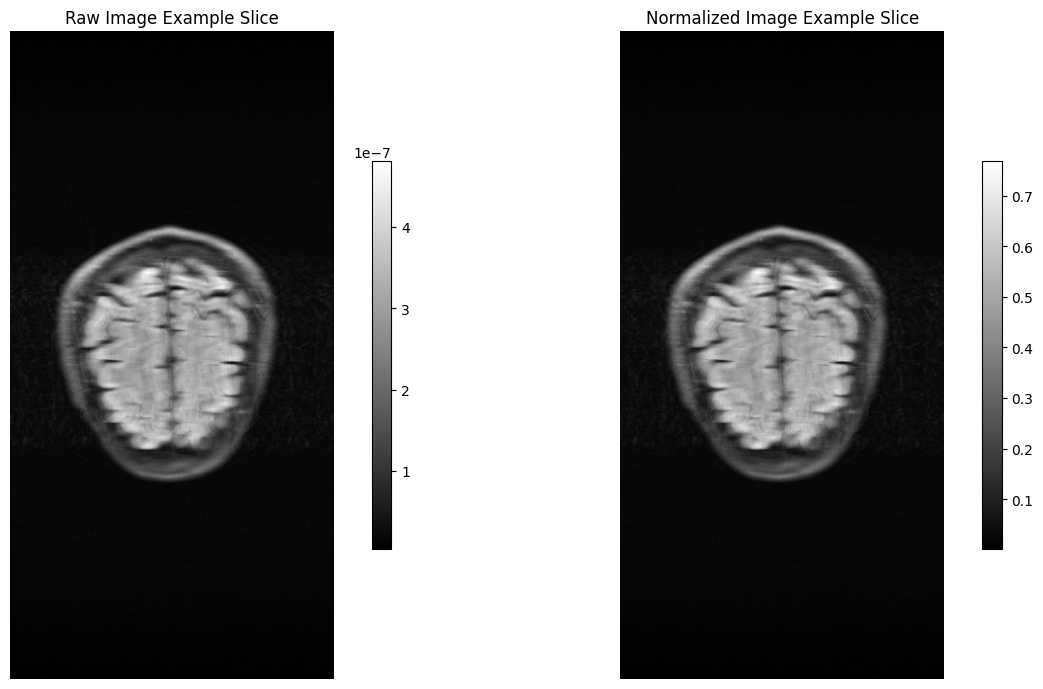


K-space visualization:
Multi-coil k-space detected with 16 coils
Using first coil for visualization: (640, 320)


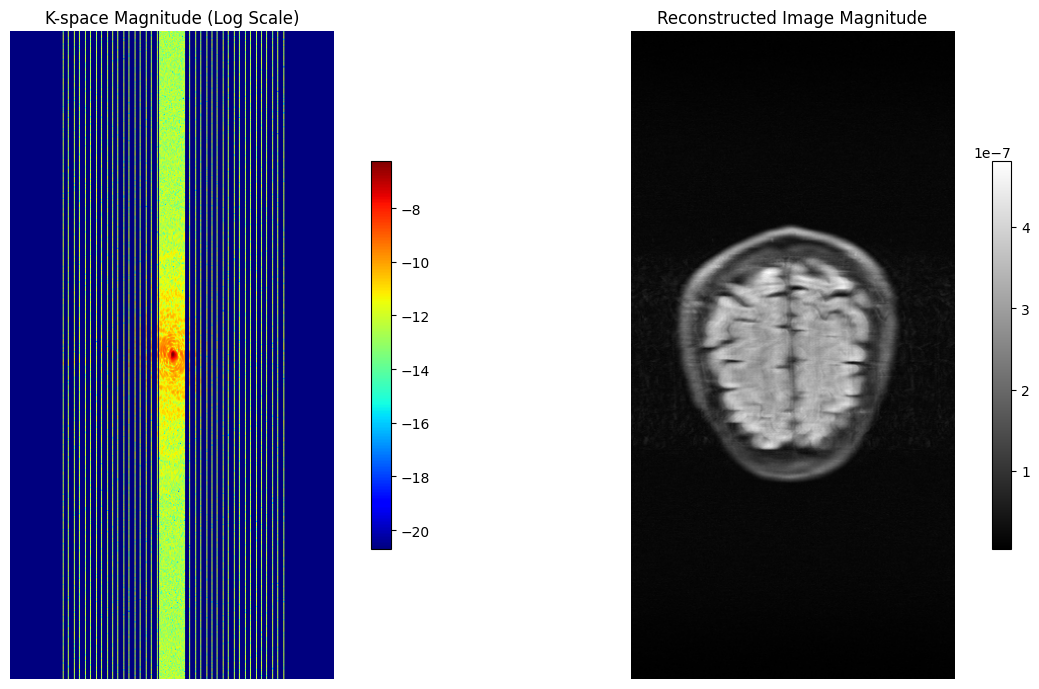


Multi-coil K-space Analysis:


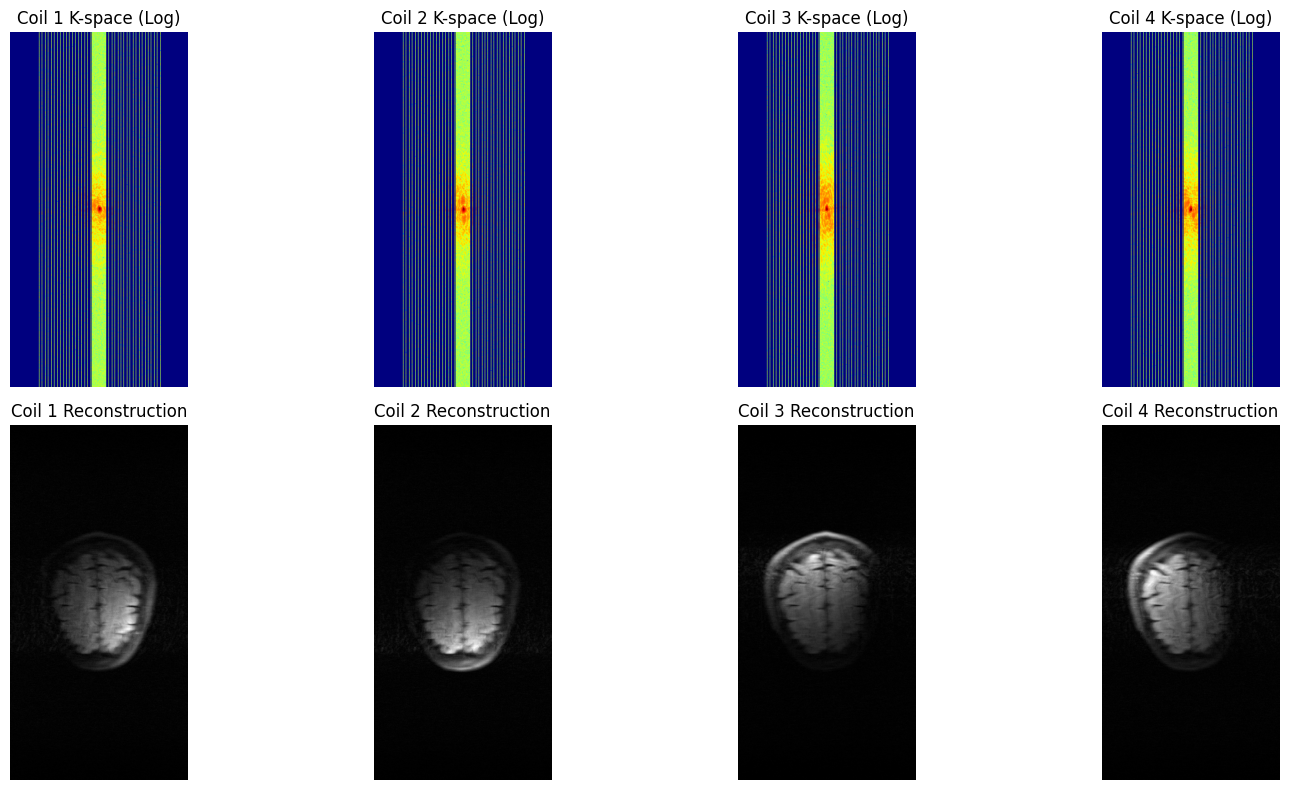


=== Data Statistics ===
Raw image - Min: 0.0000, Max: 0.0000, Mean: 0.0000
Normalized image - Min: 0.0006, Max: 0.7687, Mean: 0.0937
K-space - Shape: (16, 640, 320), Data type: complex64
K-space magnitude - Min: 0.0000, Max: 0.0030
Reconstructed magnitude - Min: 0.0000, Max: 0.0000


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Load the saved example data
try:
    raw_image_data_example = np.load('example_raw_image_slice.npy')
    normalized_image_data_example = np.load('example_normalized_image_slice.npy')

    # Check if k-space and reconstruction data exist
    kspace_available = False
    reco_available = False

    try:
        kspace_slice_example = np.load('example_kspace_slice.npy')
        kspace_available = True
        print(f"K-space data shape: {kspace_slice_example.shape}")
    except FileNotFoundError:
        print("K-space example data not found - this is normal if reconstruction wasn't needed.")

    try:
        reco_magnitude_slice_example = np.load('example_reco_magnitude_slice.npy')
        reco_available = True
        print(f"Reconstructed magnitude data shape: {reco_magnitude_slice_example.shape}")
    except FileNotFoundError:
        print("Reconstructed magnitude example data not found - this is normal if reconstruction wasn't needed.")

    print("Example data loaded successfully for visualization.")
    print(f"Raw image shape: {raw_image_data_example.shape}")
    print(f"Normalized image shape: {normalized_image_data_example.shape}")

    # --- 1. Histogram of Pixel Intensities (Before & After Normalization) ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Raw image histogram
    axes[0].hist(raw_image_data_example.flatten(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].set_title('Pixel Intensity Histogram (Raw Example Slice)')
    axes[0].set_xlabel('Pixel Value')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)

    # Normalized image histogram
    axes[1].hist(normalized_image_data_example.flatten(), bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[1].set_title('Pixel Intensity Histogram (Normalized 0-1 Example Slice)')
    axes[1].set_xlabel('Pixel Value')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- 2. Display Raw vs Normalized Images ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Raw image
    im1 = axes[0].imshow(raw_image_data_example, cmap='gray')
    axes[0].set_title('Raw Image Example Slice')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], shrink=0.6)

    # Normalized image
    im2 = axes[1].imshow(normalized_image_data_example, cmap='gray')
    axes[1].set_title('Normalized Image Example Slice')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], shrink=0.6)

    plt.tight_layout()
    plt.show()

    # --- 3. Visualizing K-space vs. Reconstructed Image (if available) ---
    if kspace_available and reco_available:
        print(f"\nK-space visualization:")

        # Handle multi-coil k-space data
        if kspace_slice_example.ndim == 3:  # (coils, height, width)
            print(f"Multi-coil k-space detected with {kspace_slice_example.shape[0]} coils")
            # Use first coil for visualization
            kspace_for_viz = kspace_slice_example[0]
            print(f"Using first coil for visualization: {kspace_for_viz.shape}")
        else:
            kspace_for_viz = kspace_slice_example
            print(f"Single coil k-space: {kspace_for_viz.shape}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 7))

        # Display K-space Magnitude (log-scaled)
        kspace_magnitude = np.abs(kspace_for_viz)
        log_kspace = np.log(kspace_magnitude + 1e-9)  # Add small epsilon to avoid log(0)

        im1 = axes[0].imshow(log_kspace, cmap='jet')
        axes[0].set_title('K-space Magnitude (Log Scale)')
        axes[0].axis('off')
        plt.colorbar(im1, ax=axes[0], shrink=0.6)

        # Display Reconstructed Image Magnitude
        im2 = axes[1].imshow(reco_magnitude_slice_example, cmap='gray')
        axes[1].set_title('Reconstructed Image Magnitude')
        axes[1].axis('off')
        plt.colorbar(im2, ax=axes[1], shrink=0.6)

        plt.tight_layout()
        plt.show()

        # --- 4. Additional K-space Analysis (if multi-coil) ---
        if kspace_slice_example.ndim == 3 and kspace_slice_example.shape[0] > 1:
            print(f"\nMulti-coil K-space Analysis:")

            # Show first few coils
            num_coils_to_show = min(4, kspace_slice_example.shape[0])
            fig, axes = plt.subplots(2, num_coils_to_show, figsize=(4*num_coils_to_show, 8))

            if num_coils_to_show == 1:
                axes = axes.reshape(2, 1)

            for i in range(num_coils_to_show):
                coil_kspace = kspace_slice_example[i]

                # K-space magnitude
                kspace_mag = np.abs(coil_kspace)
                log_kspace_coil = np.log(kspace_mag + 1e-9)

                im1 = axes[0, i].imshow(log_kspace_coil, cmap='jet')
                axes[0, i].set_title(f'Coil {i+1} K-space (Log)')
                axes[0, i].axis('off')

                # Reconstructed from this coil
                from scipy.fft import fft2, ifft2, fftshift, ifftshift
                coil_reco = ifftshift(ifft2(fftshift(coil_kspace)))
                coil_reco_mag = np.abs(coil_reco)

                im2 = axes[1, i].imshow(coil_reco_mag, cmap='gray')
                axes[1, i].set_title(f'Coil {i+1} Reconstruction')
                axes[1, i].axis('off')

            plt.tight_layout()
            plt.show()

    elif kspace_available:
        print("K-space data available but reconstructed data not found.")
    elif reco_available:
        print("Reconstructed data available but k-space data not found.")
    else:
        print("Neither k-space nor reconstructed data found - this is normal if using pre-reconstructed data.")

    # --- 5. Data Statistics ---
    print(f"\n=== Data Statistics ===")
    print(f"Raw image - Min: {np.min(raw_image_data_example):.4f}, Max: {np.max(raw_image_data_example):.4f}, Mean: {np.mean(raw_image_data_example):.4f}")
    print(f"Normalized image - Min: {np.min(normalized_image_data_example):.4f}, Max: {np.max(normalized_image_data_example):.4f}, Mean: {np.mean(normalized_image_data_example):.4f}")

    if kspace_available:
        print(f"K-space - Shape: {kspace_slice_example.shape}, Data type: {kspace_slice_example.dtype}")
        print(f"K-space magnitude - Min: {np.min(np.abs(kspace_slice_example)):.4f}, Max: {np.max(np.abs(kspace_slice_example)):.4f}")

    if reco_available:
        print(f"Reconstructed magnitude - Min: {np.min(reco_magnitude_slice_example):.4f}, Max: {np.max(reco_magnitude_slice_example):.4f}")

except FileNotFoundError as e:
    print(f"Example .npy files not found: {e}")
    print("Please ensure the preprocessing script was run successfully and created the example files.")
    print("The following files should exist in your current directory:")
    print("- example_raw_image_slice.npy")
    print("- example_normalized_image_slice.npy")
    print("- example_kspace_slice.npy (optional)")
    print("- example_reco_magnitude_slice.npy (optional)")
except Exception as e:
    print(f"An error occurred during visualization: {e}")
    import traceback
    traceback.print_exc()

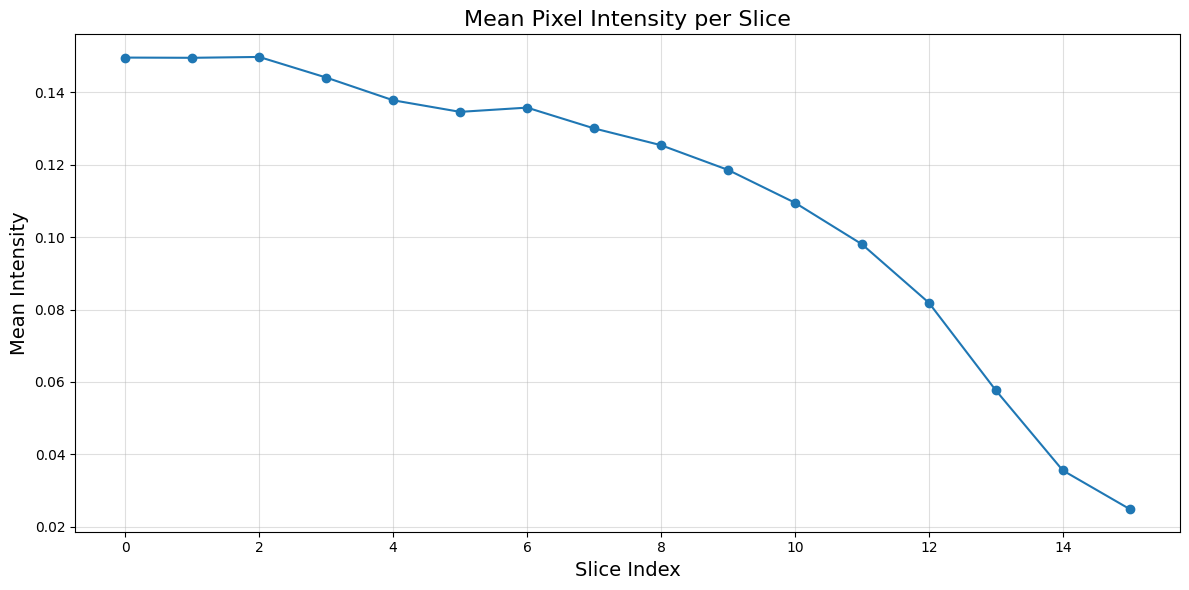

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Check the array dimensions and load data accordingly
assert normalized_image_data.ndim == 3, \
    "normalized_image_data must be a 3D array with shape (slices, height, width)"

num_slices = normalized_image_data.shape[0]

# Efficiently compute mean intensity per slice
mean_intensities = np.mean(normalized_image_data, axis=(1, 2))

plt.figure(figsize=(12, 6))
plt.plot(range(num_slices), mean_intensities, marker='o', linestyle='-')
plt.title('Mean Pixel Intensity per Slice', fontsize=16)
plt.xlabel('Slice Index', fontsize=14)
plt.ylabel('Mean Intensity', fontsize=14)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


/content/drive/My Drive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2/file_brain_AXFLAIR_201_6002891.h5 → (16, 16, 640, 320)
/content/drive/My Drive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2/file_brain_AXFLAIR_200_6002564.h5 → (16, 20, 640, 320)
/content/drive/My Drive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2/file_brain_AXFLAIR_200_6002451.h5 → (14, 20, 640, 320)
/content/drive/My Drive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2/file_brain_AXFLAIR_200_6002497.h5 → (16, 16, 640, 320)
/content/drive/My Drive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2/file_brain_AXFLAIR_201_6002921.h5 → (16, 20, 640, 320)
/content/drive/My Drive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2/file_brain_AXFLAIR_201_6002884.h5 → (16, 20, 640, 320)


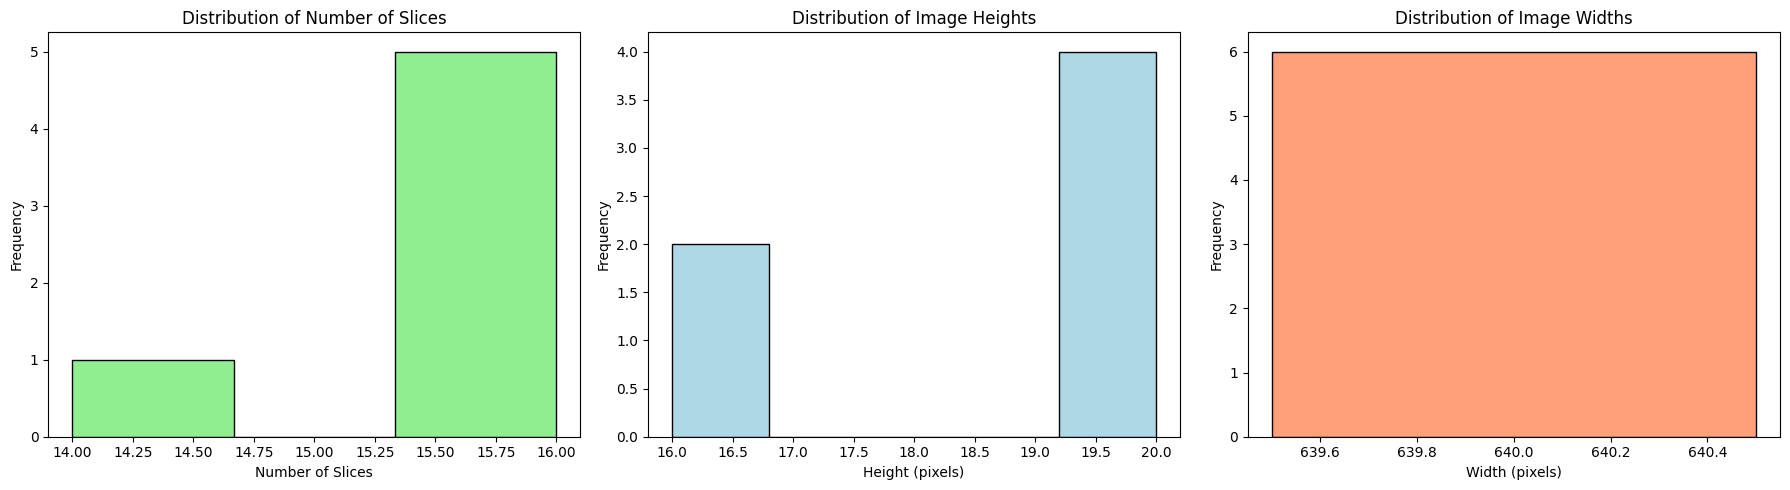

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import glob

# Define path to your .h5 files
data_path = "/content/drive/My Drive/Alzheimer_DL_detection/MRI datasets/brain_multicoil_test_batch_2/*.h5"
file_list = glob.glob(data_path)

# Collect shapes from all files
collected_shapes = []
for file_path in file_list:
    try:
        with h5py.File(file_path, 'r') as hf:
            if 'kspace' in hf:  # Change to the appropriate key if needed
                shape = hf['kspace'].shape
                collected_shapes.append(shape)
                print(f"{file_path} → {shape}")
            else:
                print(f"{file_path} → 'kspace' key not found.")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

# Visualize distributions
if collected_shapes:
    slices = [s[0] for s in collected_shapes]
    heights = [s[1] for s in collected_shapes]
    widths = [s[2] for s in collected_shapes]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(slices, bins=max(slices)-min(slices)+1, edgecolor='black', color='lightgreen')
    axes[0].set_title('Distribution of Number of Slices')
    axes[0].set_xlabel('Number of Slices')
    axes[0].set_ylabel('Frequency')

    axes[1].hist(heights, bins=max(heights)-min(heights)+1, edgecolor='black', color='lightblue')
    axes[1].set_title('Distribution of Image Heights')
    axes[1].set_xlabel('Height (pixels)')
    axes[1].set_ylabel('Frequency')

    axes[2].hist(widths, bins=max(widths)-min(widths)+1, edgecolor='black', color='lightsalmon')
    axes[2].set_title('Distribution of Image Widths')
    axes[2].set_xlabel('Width (pixels)')
    axes[2].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
else:
    print("No shapes collected to plot.")

## **Skull stripping**

In [ ]:
pip install numpy nibabel scipy antspynet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.5/190.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.3/601.3 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 84.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Su

In [ ]:
#OUT?


import os
import numpy as np
import nibabel as nib
import antspynet
import ants
from scipy.ndimage import zoom

# 1. Load NIfTI MRI volume
input_nifti = "/content/drive/MyDrive/Alzheimer_DL_detection/processed_brain_multicoil/nifti_volumes/file_brain_AXFLAIR_200_6002451.nii.gz"  # path to your input .nii or .nii.gz file
outdir = "processed_output"
os.makedirs(outdir, exist_ok=True)

# Load image using ANTsPy for compatibility with antspynet
img_ants = ants.image_read(input_nifti)
img_nib = nib.load(input_nifti)
spacing = img_ants.spacing

# 2. Resample to 1x1x1 mm isotropic voxels (if needed)
target_spacing = (1.0, 1.0, 1.0)
if not np.allclose(spacing, target_spacing, atol=0.01):
    img_ants_iso = ants.resample_image(img_ants, (1,1,1), use_voxels=False, interp_type=1)
    print(f"Resampled image from spacing {spacing} to {img_ants_iso.spacing}")
else:
    img_ants_iso = img_ants

# 3. Skull-stripping (brain extraction) with pre-trained deep learning
print("Running brain extraction...")
brain_mask = antspynet.brain_extraction(img_ants_iso, modality="t1", verbose=True)
brain_img = img_ants_iso * brain_mask

# Save skull-stripped image and mask
skullstrip_path = os.path.join(outdir, "skullstripped.nii.gz")
mask_path = os.path.join(outdir, "brainmask.nii.gz")
ants.image_write(brain_img, skullstrip_path)
ants.image_write(brain_mask, mask_path)
print(f"Saved skull-stripped MRI and brain mask.")

# 4. Intensity normalization (zero mean, unit variance inside brain mask)
brain_data = brain_img.numpy()
brain_mask_data = brain_mask.numpy().astype(bool)

mean = brain_data[brain_mask_data].mean()
std = brain_data[brain_mask_data].std()
brain_data_norm = np.zeros_like(brain_data)
brain_data_norm[brain_mask_data] = (brain_data[brain_mask_data] - mean) / std

# Save normalized image as NIfTI
norm_path = os.path.join(outdir, "skullstripped_normalized.nii.gz")
brain_img_norm = ants.from_numpy(brain_data_norm, origin=brain_img.origin, spacing=brain_img.spacing, direction=brain_img.direction)
ants.image_write(brain_img_norm, norm_path)
print(f"Saved intensity-normalized skull-stripped MRI.")

# 5. (Optional) Center crop/pad to standard size, e.g. 128x128x128 or 120x120x120 (used in many DL papers)
def crop_or_pad(img, out_shape=(120,120,120)):
    arr = img.numpy()
    result = np.zeros(out_shape, dtype=arr.dtype)
    # compute crop or pad start indices for each axis
    for i in range(3):
        start = max((arr.shape[i] - out_shape[i]) // 2, 0)
        end = start + out_shape[i]
        crop = arr[start:end] if arr.shape[i] > out_shape[i] else arr
        if crop.shape[i] < out_shape[i]:
            pad_width = [(0,0)]*3
            pad_width[i] = (0, out_shape[i] - crop.shape[i])
            crop = np.pad(crop, pad_width, mode='constant')
        arr = crop
    return arr

cropped = crop_or_pad(brain_img_norm, out_shape=(120,120,120))
cropped_path = os.path.join(outdir, "cropped_normalized.nii.gz")
cropped_nifti = nib.Nifti1Image(cropped, np.eye(4))
nib.save(cropped_nifti, cropped_path)
print(f"Saved cropped/padded image.")

# 6. (Optional) Brain Tissue Segmentation (ANTsPyNet, returns GM/WM/CSF etc.)
# Note: This requires more RAM (~8GB+) and can be slow
# print("Running segmentation...")
# tissue_seg = antspynet.t1_brain_segmentation(brain_img, verbose=True)['segmentation_image']
# seg_path = os.path.join(outdir, "tissue_segmentation.nii.gz")
#ants.image_write(tissue_seg, seg_path)
# print(f"Saved tissue segmentation labelmap.")



Running brain extraction...
Brain extraction:  retrieving model weights.
Brain extraction:  retrieving template.
Brain extraction:  normalizing image to the template.
Brain extraction:  prediction and decoding.


1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
Brain extraction:  renormalize probability mask to native space.
Saved skull-stripped MRI and brain mask.
Saved intensity-normalized skull-stripped MRI.
Saved cropped/padded image.


In [ ]:
import os
import numpy as np
import nibabel as nib
from PIL import Image
from scipy import ndimage
from scipy.ndimage import binary_fill_holes, binary_opening, binary_closing
from skimage import morphology, measure
from skimage.filters import threshold_otsu
import warnings
warnings.filterwarnings('ignore')

# --- Directories ---
input_nifti_folder = "/content/drive/My Drive/Alzheimer_DL_detection/processed_brain_multicoil/nifti_volumes"
output_folder_skull_stripped = "/content/drive/My Drive/Alzheimer_DL_detection/processed_brain_multicoil/skull_stripped"
os.makedirs(output_folder_skull_stripped, exist_ok=True)

# --- 2D Morphological Skull Stripping Function ---
def morphological_skull_strip_2d(image_slice, intensity_threshold=0.1):

# Calculate an optimal threshold using Otsu's method; fallback on intensity_threshold if necessary.
    try:
        otsu_thresh = threshold_otsu(image_slice)
        thresh = max(otsu_thresh, intensity_threshold)
    except:
        thresh = intensity_threshold
# Create a binary mask of potential brain regions using the threshold
    brain_mask = image_slice > thresh

# Identify the largest connected component; assume this is the brain.
    labeled_mask = measure.label(brain_mask)
    if labeled_mask.max() > 0:
        props = measure.regionprops(labeled_mask)
        largest = max(props, key=lambda x: x.area)
        brain_mask = labeled_mask == largest.label

# Fill holes in the brain mask to achieve continuity.
    brain_mask = binary_fill_holes(brain_mask)

# Apply morphological opening and closing to remove noise and smooth boundaries.
    kernel_size = max(3, min(image_slice.shape) // 100)
    kernel = morphology.disk(kernel_size)
    brain_mask = binary_opening(brain_mask, kernel)
    brain_mask = binary_closing(brain_mask, kernel)

    # Smooth boundary by eroding slightly
    distance = ndimage.distance_transform_edt(brain_mask)
    if np.any(distance > 0):
        erosion_threshold = np.percentile(distance[distance > 0], 20)
    else:
        erosion_threshold = 0
    brain_mask_refined = distance > erosion_threshold
    brain_mask_refined = binary_fill_holes(brain_mask_refined)

    skull_stripped_slice = image_slice * brain_mask_refined
    return skull_stripped_slice, brain_mask_refined

def morphological_skull_strip_3d(volume, intensity_threshold=0.1):
    num_slices = volume.shape[-1]
    skull_stripped_volume = np.zeros_like(volume)
    brain_masks = np.zeros_like(volume, dtype=bool)

    for i in range(num_slices):
        slice_data = volume[:,:,i]
        if np.max(slice_data) < intensity_threshold:
            continue
        stripped_slice, brain_mask = morphological_skull_strip_2d(slice_data, intensity_threshold)
        skull_stripped_volume[:,:,i] = stripped_slice
        brain_masks[:,:,i] = brain_mask

    kernel_3d = morphology.ball(2)
    brain_masks = binary_closing(brain_masks, kernel_3d)
    brain_masks = binary_opening(brain_masks, kernel_3d)
    skull_stripped_volume = volume * brain_masks

    return skull_stripped_volume, brain_masks

# ---- MAIN PIPELINE ----
nifti_files = [f for f in os.listdir(input_nifti_folder) if f.endswith('.nii.gz')]
print(f"Found {len(nifti_files)} NIfTI volumes to process.")

for filename in nifti_files:
    scan_id = os.path.splitext(os.path.splitext(filename)[0])[0]
    file_path = os.path.join(input_nifti_folder, filename)
    print(f"\nProcessing {filename} ...")

    try:
        img = nib.load(file_path)
        data = img.get_fdata()
        affine = img.affine

        if data.ndim == 3:
            # We expect (height, width, slices)
            print(f"  Image shape: {data.shape}")
            data = data.astype(np.float32)
        else:
            print(f"  Unexpected data shape: {data.shape} ... skipping")
            continue

        # Skull stripping
        print(f"  Performing skull stripping ...")
        skull_stripped, brain_mask = morphological_skull_strip_3d(data)
        print(f"    Skull stripping complete.")

        # Save skull-stripped NIfTI
        stripped_img = nib.Nifti1Image(skull_stripped.astype(np.float32), affine)
        stripped_path = os.path.join(output_folder_skull_stripped, f"{scan_id}_skull_stripped.nii.gz")
        nib.save(stripped_img, stripped_path)

        # Save brain mask NIfTI
        mask_img = nib.Nifti1Image(brain_mask.astype(np.float32), affine)
        mask_path = os.path.join(output_folder_skull_stripped, f"{scan_id}_brain_mask.nii.gz")
        nib.save(mask_img, mask_path)

        # Save slices as PNG
        for i in range(data.shape[2]):
            orig_slice = data[:,:,i]
            skull_stripped_slice = skull_stripped[:,:,i]

            orig_png = (orig_slice * 255).clip(0,255).astype(np.uint8)
            stripped_png = (skull_stripped_slice * 255).clip(0,255).astype(np.uint8)
            orig_png_path = os.path.join(output_folder_skull_stripped, f"{scan_id}_slice_{i:03d}.png")
            stripped_png_path = os.path.join(output_folder_skull_stripped, f"{scan_id}_slice_{i:03d}_skull_stripped.png")
            Image.fromarray(orig_png).save(orig_png_path)
            Image.fromarray(stripped_png).save(stripped_png_path)

        print(f"  Finished processing {filename}")

    except Exception as e:
        print(f"  Error processing {filename}: {e}")

print("All NIfTI volumes processed.")


Found 7 NIfTI volumes to process.

Processing file_brain_AXFLAIR_201_6002891.nii.gz ...
  Image shape: (640, 320, 16)
  Performing skull stripping ...
    Skull stripping complete.
  Finished processing file_brain_AXFLAIR_201_6002891.nii.gz

Processing file_brain_AXFLAIR_200_6002564.nii.gz ...
  Image shape: (640, 320, 16)
  Performing skull stripping ...
    Skull stripping complete.
  Finished processing file_brain_AXFLAIR_200_6002564.nii.gz

Processing file_brain_AXFLAIR_200_6002451.nii.gz ...
  Image shape: (640, 320, 14)
  Performing skull stripping ...
    Skull stripping complete.
  Finished processing file_brain_AXFLAIR_200_6002451.nii.gz

Processing file_brain_AXFLAIR_200_6002497.nii.gz ...
  Image shape: (640, 320, 16)
  Performing skull stripping ...
    Skull stripping complete.
  Finished processing file_brain_AXFLAIR_200_6002497.nii.gz

Processing file_brain_AXFLAIR_201_6002921.nii.gz ...
  Image shape: (640, 320, 16)
  Performing skull stripping ...
    Skull stripping c

## Visualization of skull stripping

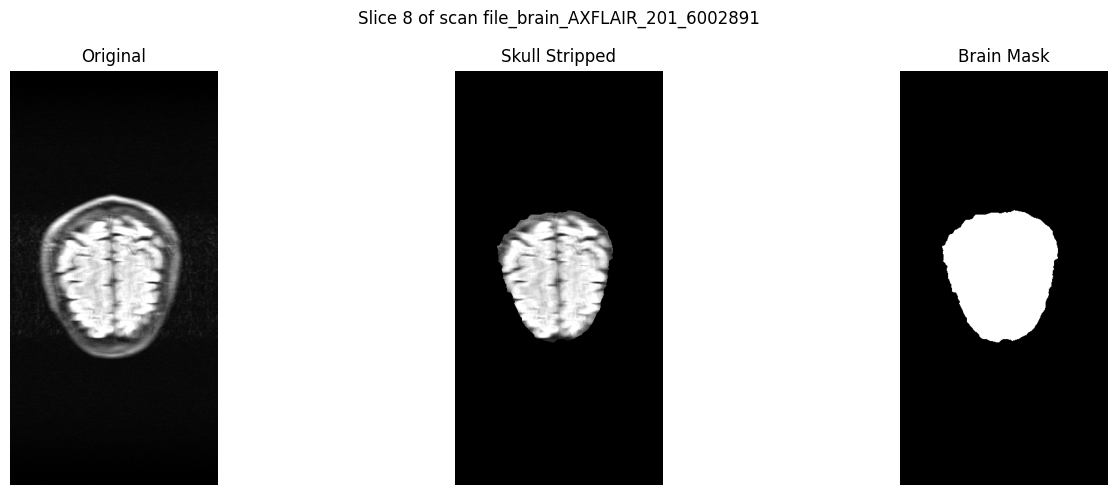

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import os

# Specify scan ID and folder paths
scan_id = "file_brain_AXFLAIR_201_6002891"
input_nifti_folder = "/content/drive/My Drive/Alzheimer_DL_detection/processed_brain_multicoil/nifti_volumes"
skull_stripped_folder = "/content/drive/My Drive/Alzheimer_DL_detection/processed_brain_multicoil/skull_stripped"

# Build file paths
original_path = os.path.join(input_nifti_folder, f"{scan_id}.nii.gz")
stripped_path = os.path.join(skull_stripped_folder, f"{scan_id}_skull_stripped.nii.gz")
mask_path = os.path.join(skull_stripped_folder, f"{scan_id}_brain_mask.nii.gz")

# Load volumes
original_img = nib.load(original_path).get_fdata()
stripped_img = nib.load(stripped_path).get_fdata()
mask_img = nib.load(mask_path).get_fdata()

# Select slice index (you can adjust this as needed)
slice_idx = original_img.shape[2] // 2

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_img[:, :, slice_idx], cmap="gray")
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(stripped_img[:, :, slice_idx], cmap="gray")
axes[1].set_title("Skull Stripped")
axes[1].axis('off')

axes[2].imshow(mask_img[:, :, slice_idx], cmap="gray")
axes[2].set_title("Brain Mask")
axes[2].axis('off')

plt.suptitle(f'Slice {slice_idx} of scan {scan_id}')
plt.tight_layout()
plt.show()


In [ ]:
# Load the NIfTI file
example_ni1 = os.path.join("/content/drive/My Drive/Alzheimer_DL_detection/processed_brain_multicoil/skull_stripped", 'file_brain_AXFLAIR_201_6002891_skull_stripped.nii.gz')
img = nib.load(example_ni1)
nib.save(img, 'saved_data.nii')

# Extract image data as a NumPy array
mri_data = img.get_fdata()

# Display basic info
print("Image Shape:", mri_data.shape)
print("Voxel Size:", img.header.get_zooms())  # Voxel resolution

Image Shape: (640, 320, 16)
Voxel Size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


In [ ]:
# Contains metadata of the image
print(img.header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'')
dim_info        : 0
dim             : [  3 640 320  16   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [1. 1. 1. 1. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'')
aux_file        : np.bytes_(b'')
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 0.0
qoffset_x       : 0.0
qoffset_y       : 0.0
qoffset_z       : 0.0


In [ ]:
# NIfTI images have an affine relating the voxel coordinates to world coordinates in RAS+ Space
img.affine

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

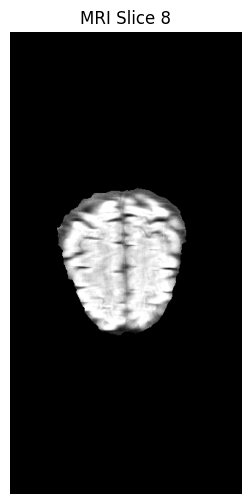

In [ ]:
# Sometimes MRI data contain 4 dimensions, these are mainly to contain extra modalities like time-series data
if len(mri_data.shape) == 4:
    mri_data = mri_data[:, :, :, 0]

# Select a middle slice along the Z-axis
slice_idx = mri_data.shape[2] // 2  # Middle slice

# Plot the MRI slice
plt.figure(figsize=(6,6))
plt.imshow(mri_data[:, :, slice_idx], cmap="gray")
plt.title(f"MRI Slice {slice_idx}")
plt.axis("off")
plt.show()

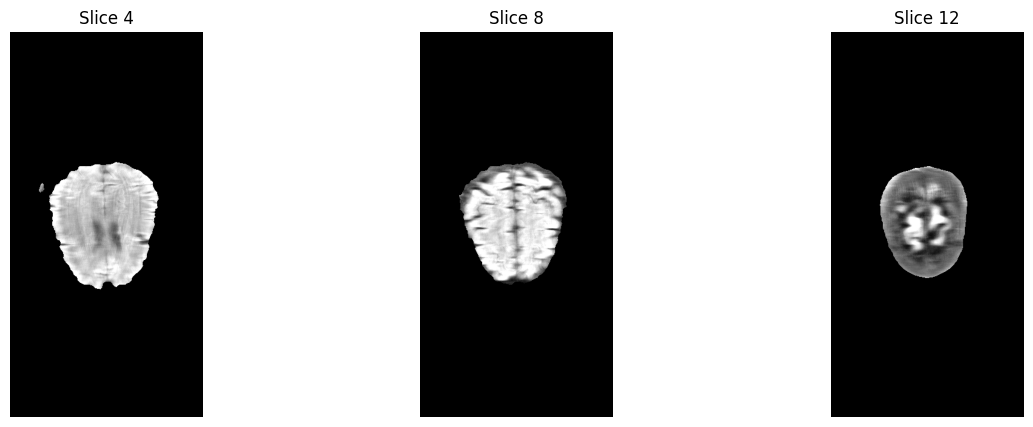

In [ ]:
# Select a few slices
slice_indices = [mri_data.shape[2] // 4, mri_data.shape[2] // 2, 3 * mri_data.shape[2] // 4]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, idx in enumerate(slice_indices):
    axes[i].imshow(mri_data[:, :, idx], cmap="gray")
    axes[i].set_title(f"Slice {idx}")
    axes[i].axis("off")

plt.show()

In [ ]:
print(f"Path to MNI152 template: {os.path.join('/content/drive/My Drive/Alzheimer_DL_detection/processed_brain_multicoil/skull_stripped', 'file_brain_AXFLAIR_201_6002891_skull_stripped.nii.gz')}")


Path to MNI152 template: /content/drive/My Drive/Alzheimer_DL_detection/processed_brain_multicoil/skull_stripped/file_brain_AXFLAIR_201_6002891_skull_stripped.nii.gz
